In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
print(df.shape)

print(df.columns)

df.info()

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non

In [42]:
# Check missing values
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [43]:
for col in df.columns:
    print("Column name:- ", col ,(df[col] == " ").sum())

Column name:-  customerID 0
Column name:-  gender 0
Column name:-  SeniorCitizen 0
Column name:-  Partner 0
Column name:-  Dependents 0
Column name:-  tenure 0
Column name:-  PhoneService 0
Column name:-  MultipleLines 0
Column name:-  InternetService 0
Column name:-  OnlineSecurity 0
Column name:-  OnlineBackup 0
Column name:-  DeviceProtection 0
Column name:-  TechSupport 0
Column name:-  StreamingTV 0
Column name:-  StreamingMovies 0
Column name:-  Contract 0
Column name:-  PaperlessBilling 0
Column name:-  PaymentMethod 0
Column name:-  MonthlyCharges 0
Column name:-  TotalCharges 11
Column name:-  Churn 0


In [44]:
# Replace blank spaces with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [45]:
# Convert to numeric datatype
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [46]:
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [47]:
df.dropna(inplace=True)

In [48]:
print(df.shape)

(7032, 21)


In [49]:
print(df.duplicated().sum())

0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [61]:
print("Percentage of churn customer among all the dataset ", (df[df["Churn"]=="Yes"].shape[0]/df[df["Churn"]=="No"].shape[0])*100)

Percentage of churn customer among all the dataset  36.199883788495065


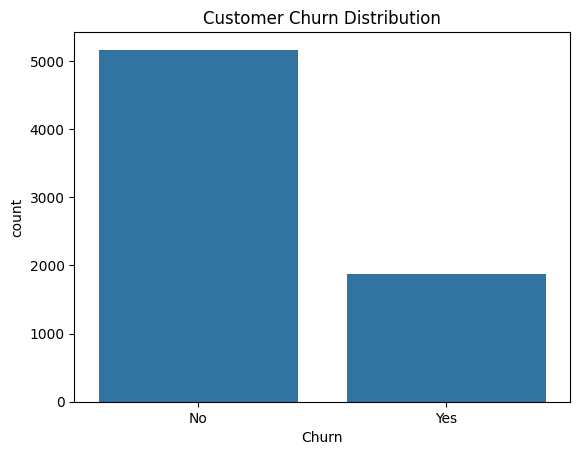

In [51]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

Majority of customers did not churn, but a significant number left the telecom service.

In [74]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100

print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


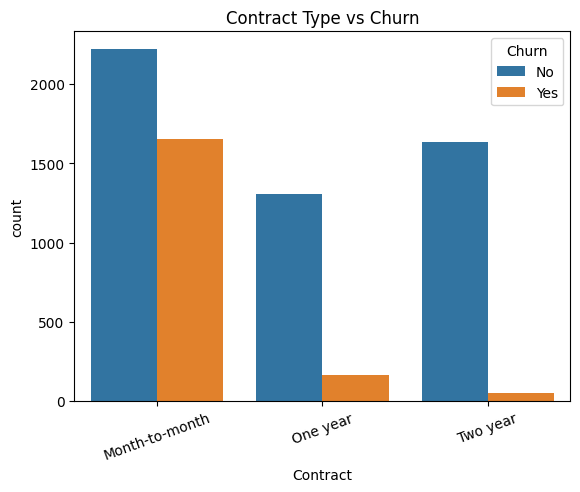

In [63]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.xticks(rotation=20)

plt.title("Contract Type vs Churn")

plt.show()

This indicates month-to-month customers churn more

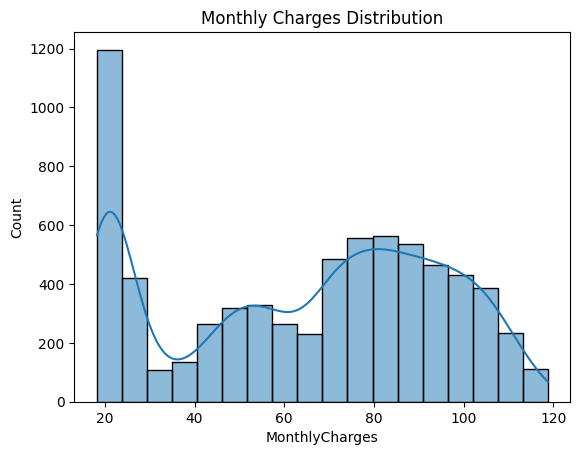

In [64]:
sns.histplot(df["MonthlyCharges"], kde=True)

plt.title("Monthly Charges Distribution")

plt.show()

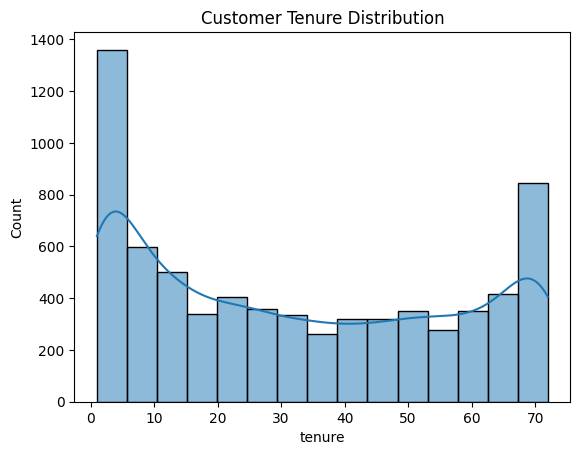

In [65]:
sns.histplot(df["tenure"], kde=True)

plt.title("Customer Tenure Distribution")

plt.show()

In [66]:
df["Churn_binary"] = df["Churn"].map({"Yes":1, "No":0})

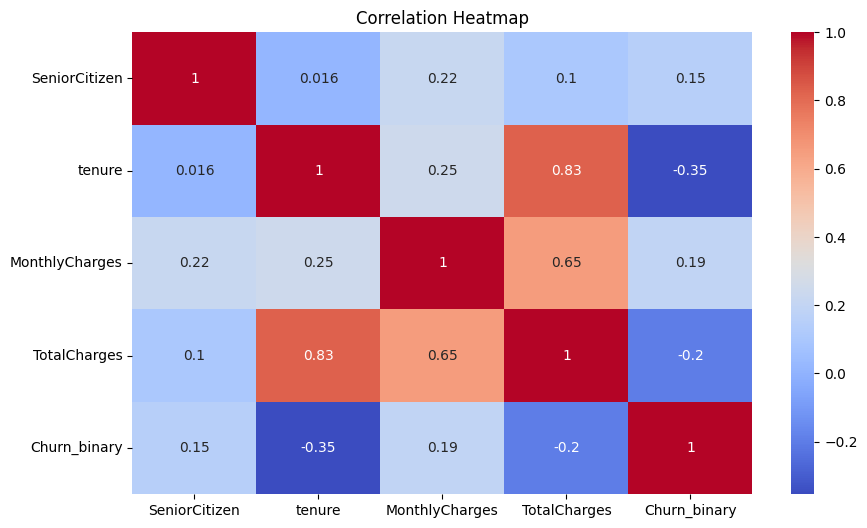

In [67]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

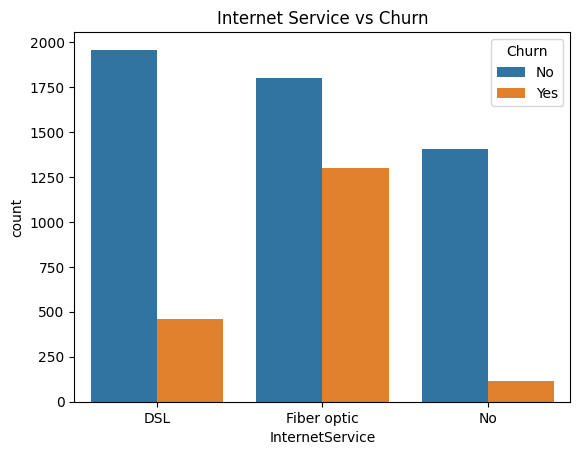

In [68]:
sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Internet Service vs Churn")

plt.show()

Fiber optic customers showed higher churn rates.

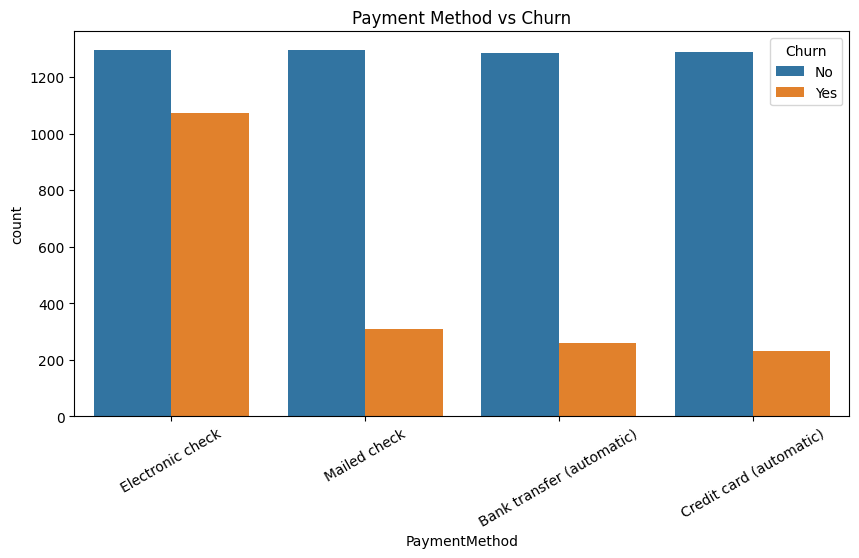

In [69]:
plt.figure(figsize=(10,5))

sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=30)

plt.title("Payment Method vs Churn")

plt.show()

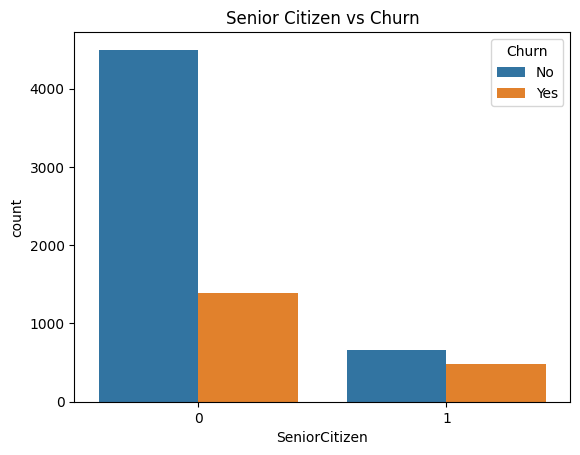

In [70]:
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)

plt.title("Senior Citizen vs Churn")

plt.show()

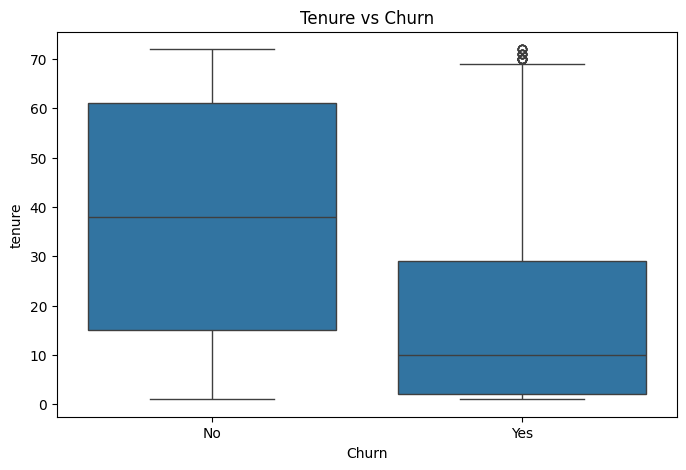

In [71]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure vs Churn")

plt.show()

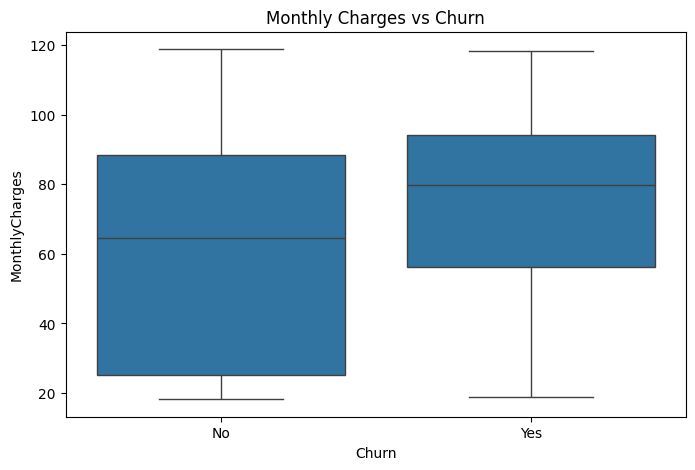

In [72]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

Customers with higher monthly charges tend to churn more.

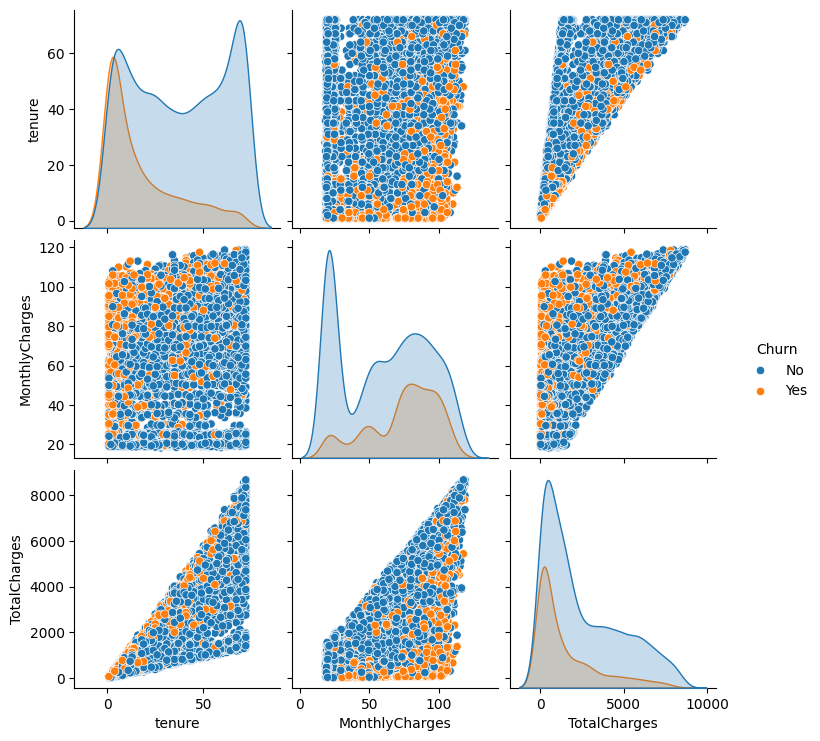

In [75]:
sns.pairplot(
    df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]],
    hue="Churn"
)

plt.show()

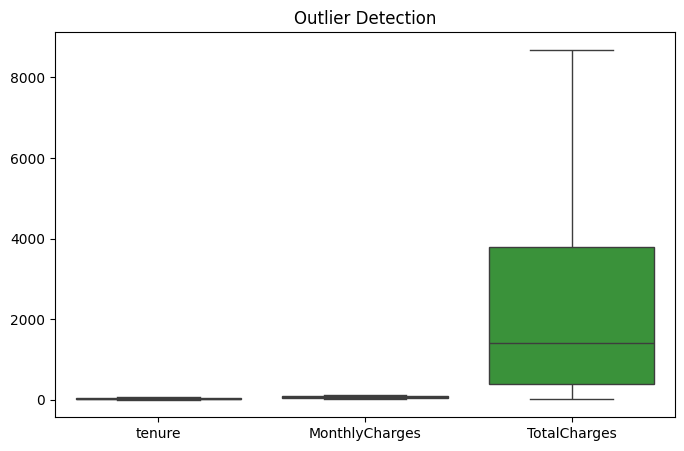

In [76]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df[["tenure", "MonthlyCharges", "TotalCharges"]])

plt.title("Outlier Detection")

plt.show()

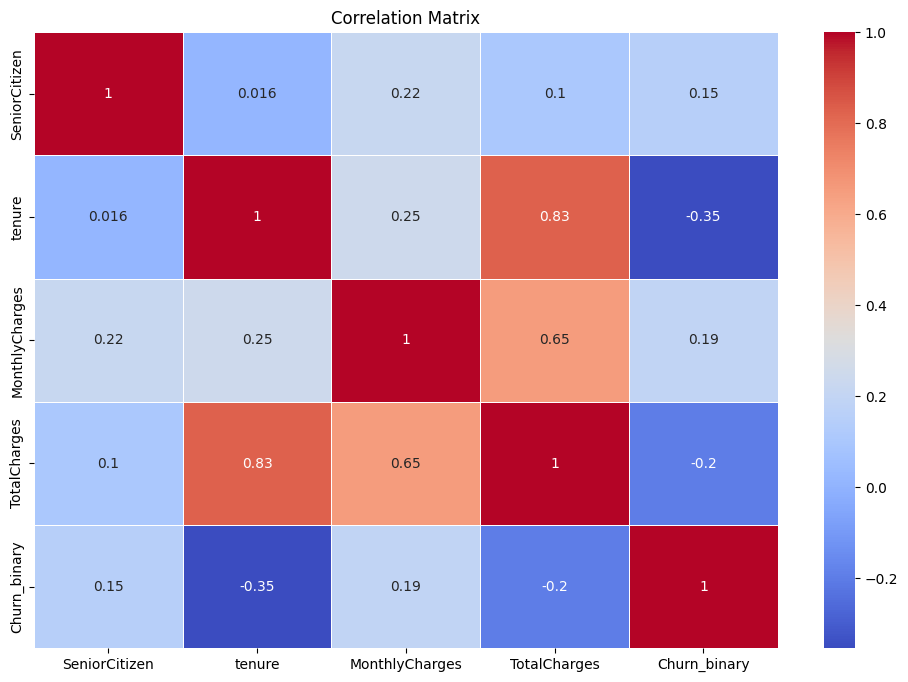

In [77]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

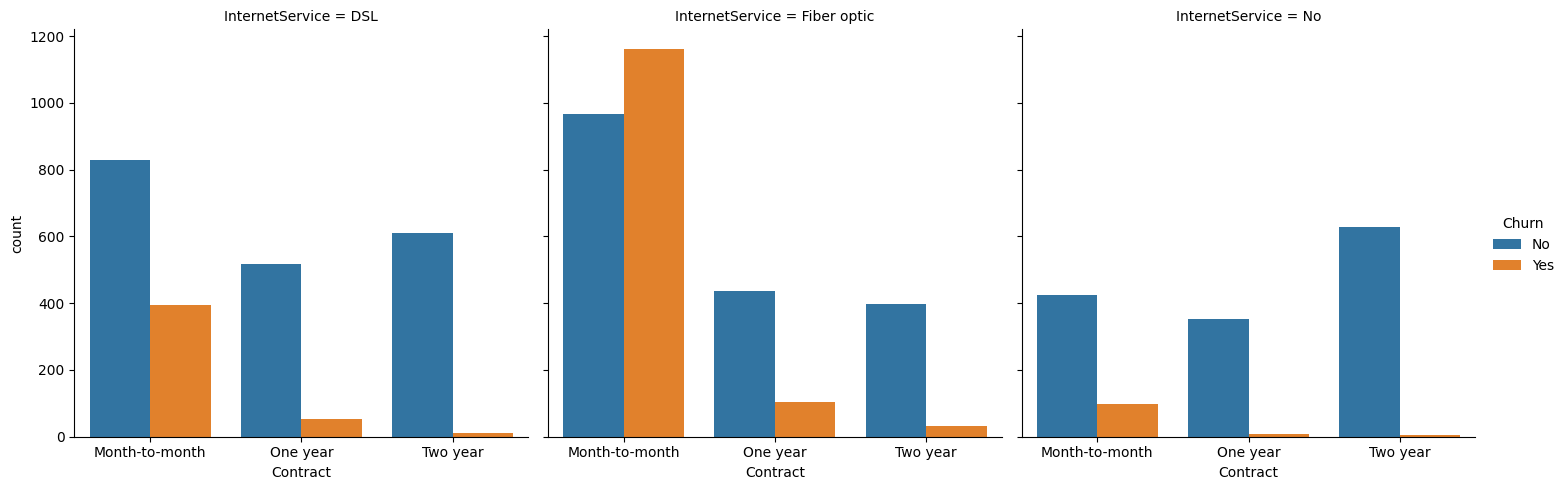

In [78]:
sns.catplot(
    x="Contract",
    hue="Churn",
    col="InternetService",
    data=df,
    kind="count"
)

plt.show()

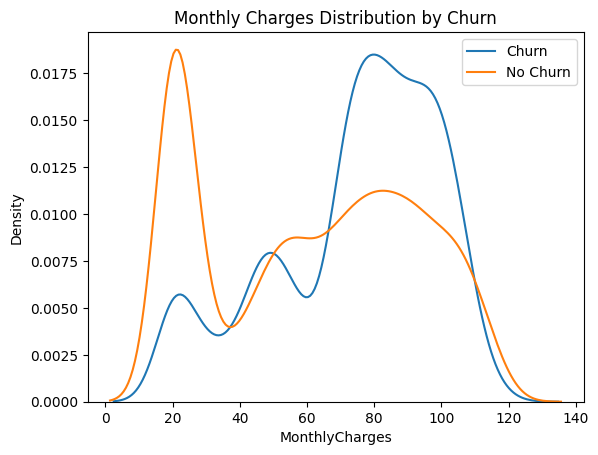

In [79]:
sns.kdeplot(data=df[df["Churn"]=="Yes"]["MonthlyCharges"], label="Churn")

sns.kdeplot(data=df[df["Churn"]=="No"]["MonthlyCharges"], label="No Churn")

plt.legend()

plt.title("Monthly Charges Distribution by Churn")

plt.show()

In [80]:
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

In [81]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


HYPOTHESIS TESTING — TEST 1
T-Test
Monthly Charges vs Churn
Research Hypothesis
Null Hypothesis (H0)

Monthly charges do not significantly affect customer churn.

Alternative Hypothesis (H1)

Monthly charges significantly affect customer churn.

In [83]:
churn_yes = df[df["Churn"] == "Yes"]["MonthlyCharges"]

churn_no = df[df["Churn"] == "No"]["MonthlyCharges"]
t_stat, p_value = ttest_ind(churn_yes, churn_no)

print("T-Statistic:", t_stat)

print("P-Value:", p_value)

T-Statistic: 16.47959313114872
P-Value: 6.760843117980302e-60


Interpretation for Report
Null Hypothesis (H0)

There is no significant difference in monthly charges between churned and non-churned customers.

Alternative Hypothesis (H1)

There is a significant difference in monthly charges between churned and non-churned customers.

Decision

Since the p-value is less than 0.05, the null hypothesis is rejected.

Conclusion

Monthly charges significantly influence customer churn. Customers with higher monthly charges are more likely to churn.

HYPOTHESIS TESTING — TEST 2
Chi-Square Test
Contract Type vs Churn

This is excellent for churn analysis.

Research Hypothesis
H0

Contract type has no association with customer churn.

H1

Contract type significantly affects customer churn.

In [84]:
contingency_table = pd.crosstab(df["Contract"], df["Churn"])

print(contingency_table)

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1306   166
Two year        1637    48


In [85]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Value:", chi2)

print("P-Value:", p)

Chi-Square Value: 1179.5458287339445
P-Value: 7.326182186265472e-257


Interpretation for Report
Null Hypothesis (H0)

Contract type and customer churn are independent.

Alternative Hypothesis (H1)

Contract type and customer churn are associated.

Decision

Since the p-value is less than 0.05, the null hypothesis is rejected.

Conclusion

Contract type has a significant impact on customer churn. Customers with month-to-month contracts show higher churn rates compared to one-year and two-year contracts.